# Carve‑Out Dependency Mapper — System & Supplier Entanglement Analysis

**Purpose**  
- Identify, quantify, and visualise **hidden system, supplier, and data entanglements** that materially affect:
    - Day‑1 operability
    - TSA duration and cost
    - Separation risk and timing

The modelling is intentionally conservative and non‑optimistic, reflecting how carve‑outs fail in practice

## 1. Imports

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## 2. Separation Context

In [10]:
# Nodes represent systems, suppliers, or shared functions
# Edges represent dependency direction

dependencies = [
    ("ERP_Core", "Order_Management"),
    ("ERP_Core", "Finance_Reporting"),
    ("MES", "Production_Line_A"),
    ("MES", "Production_Line_B"),
    ("Supplier_A", "Production_Line_A"),
    ("Supplier_B", "Production_Line_B"),
    ("Shared_Data_Lake", "Finance_Reporting"),
    ("Shared_Data_Lake", "Demand_Planning"),
    ("Identity_Access", "ERP_Core"),
    ("Identity_Access", "MES"),
    ("Parent_Network", "ERP_Core"),
    ("Parent_Network", "Shared_Data_Lake")
]

## 3. Build Dependency Graph

In [11]:
G = nx.DiGraph()
G.add_edges_from(dependencies)

G

## 4. Visualise Dependency Network

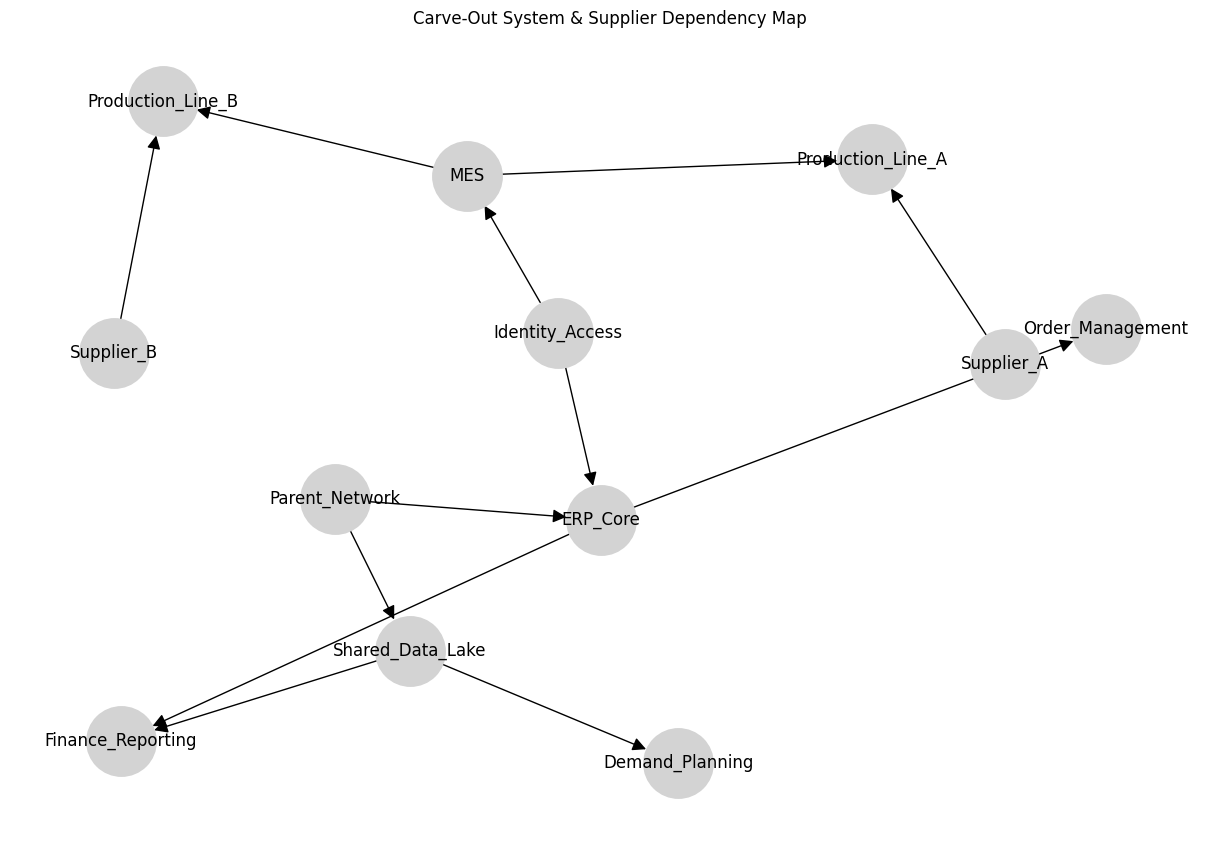

In [12]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.8)
nx.draw(G, pos, with_labels=True, node_size=2500, node_color='lightgrey', arrowsize=20)
plt.title("Carve‑Out System & Supplier Dependency Map")
plt.show()

## 5. Criticality Metrics

In [13]:
# Degree centrality highlights entangled systems
degree_centrality = nx.degree_centrality(G)

# Betweenness identifies separation bottlenecks
betweenness = nx.betweenness_centrality(G)

degree_centrality, betweenness

({'ERP_Core': 0.36363636363636365,
  'Order_Management': 0.09090909090909091,
  'Finance_Reporting': 0.18181818181818182,
  'MES': 0.2727272727272727,
  'Production_Line_A': 0.18181818181818182,
  'Production_Line_B': 0.18181818181818182,
  'Supplier_A': 0.09090909090909091,
  'Supplier_B': 0.09090909090909091,
  'Shared_Data_Lake': 0.2727272727272727,
  'Demand_Planning': 0.09090909090909091,
  'Identity_Access': 0.18181818181818182,
  'Parent_Network': 0.18181818181818182},
 {'ERP_Core': 0.031818181818181815,
  'Order_Management': 0.0,
  'Finance_Reporting': 0.0,
  'MES': 0.01818181818181818,
  'Production_Line_A': 0.0,
  'Production_Line_B': 0.0,
  'Supplier_A': 0.0,
  'Supplier_B': 0.0,
  'Shared_Data_Lake': 0.013636363636363636,
  'Demand_Planning': 0.0,
  'Identity_Access': 0.0,
  'Parent_Network': 0.0})

## 6. Identify Separation Bottlenecks

In [14]:
bottlenecks = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)
bottlenecks

[('ERP_Core', 0.031818181818181815),
 ('MES', 0.01818181818181818),
 ('Shared_Data_Lake', 0.013636363636363636),
 ('Order_Management', 0.0),
 ('Finance_Reporting', 0.0),
 ('Production_Line_A', 0.0),
 ('Production_Line_B', 0.0),
 ('Supplier_A', 0.0),
 ('Supplier_B', 0.0),
 ('Demand_Planning', 0.0),
 ('Identity_Access', 0.0),
 ('Parent_Network', 0.0)]

## 7. Failure Impact Simulation

In [15]:
# Remove each node and measure operational impact
impact = {}
base_components = nx.number_weakly_connected_components(G)

for node in G.nodes():
    G_temp = G.copy()
    G_temp.remove_node(node)
    impact[node] = nx.number_weakly_connected_components(G_temp) - base_components

impact

{'ERP_Core': 2,
 'Order_Management': 0,
 'Finance_Reporting': 0,
 'MES': 2,
 'Production_Line_A': 1,
 'Production_Line_B': 1,
 'Supplier_A': 0,
 'Supplier_B': 0,
 'Shared_Data_Lake': 1,
 'Demand_Planning': 0,
 'Identity_Access': 1,
 'Parent_Network': 0}

## 8. TSA Risk Scoring

In [16]:
# Simple TSA risk score combining criticality and impact
tsa_risk_score = {}
for node in G.nodes():
    tsa_risk_score[node] = degree_centrality[node] + betweenness[node] + max(impact[node], 0)

tsa_risk_score

{'ERP_Core': 2.3954545454545455,
 'Order_Management': 0.09090909090909091,
 'Finance_Reporting': 0.18181818181818182,
 'MES': 2.290909090909091,
 'Production_Line_A': 1.1818181818181819,
 'Production_Line_B': 1.1818181818181819,
 'Supplier_A': 0.09090909090909091,
 'Supplier_B': 0.09090909090909091,
 'Shared_Data_Lake': 1.2863636363636364,
 'Demand_Planning': 0.09090909090909091,
 'Identity_Access': 1.1818181818181819,
 'Parent_Network': 0.18181818181818182}

## 9. Deal Interpretation


The analysis highlights **non‑obvious separation failures** driven by:
- Identity and access coupling
- Shared data platforms
- Parent‑level network dependencies

These nodes typically dictate:
- TSA length
- Day‑1 fragility
- True separation cost

The mapper is designed to be updated iteratively as diligence uncovers new dependencies.
